**Name of student:** Kamar Chakroun |
**Group:** Ecology Class |
**AI used :** Claude (Anthropic)

**Tasks I worked on (Pipeline):** Sequential Mining, Time Series, Text Mining, Deep Learning, Recommender Systems.

## Environment Setup :
- Downloaded packages in bulk, used sys.executable for direct configuration of the environment
- Configured the **nltk** and **spacy** packages

In [1]:
import subprocess, sys
packages = ['mlxtend','nltk','textblob','gensim','scikit-surprise','statsmodels','torch','torchvision','spacy', 'statsmodels']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)
import nltk
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
subprocess.run([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm'], check=False)
print('Ready.')


Ready.


## Imports:
- Imported libraries 
- Defined path of data [the million songs and the lyrics data]

In [2]:
import os, sqlite3, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
warnings.filterwarnings('ignore')

DATA_PATH   = 'C:/Users/GIGABYTE/Documents/mse/eng_2/sem2/DM/recom_sys/millionsongsubset'
LYRICS_PATH = 'C:/Users/GIGABYTE/Documents/mse/eng_2/sem2/DM/recom_sys/mxm_dataset.db'

plt.rcParams['figure.figsize'] = (12, 5)
print('Imports done.')
print(f'Data path  : {DATA_PATH}')
print(f'Lyrics path: {LYRICS_PATH}')

Imports done.
Data path  : C:/Users/GIGABYTE/Documents/mse/eng_2/sem2/DM/recom_sys/millionsongsubset
Lyrics path: C:/Users/GIGABYTE/Documents/mse/eng_2/sem2/DM/recom_sys/mxm_dataset.db


## Data Loading:
- Followed a similar approach to the one provided in the notebook <br />
**Function: get_all_lyrics_mapped:** It connects the database to fetch the lyrics<br />
**Function: load_MillionSongDataset:** Main data loader, ikt recursively scams the directory to extract the files <br />
**Function: SimpleData:** this fct generates data in case we failed to extract real data from the datasets <br />
**Function: generate_user_history:** this fct simulates user interaction by simulating 500 user and for each user selects batch of songs and assigns random ratings, timestamp and listening order

**RQ: I had to create the hdf5_getters file manually because it wouldnt install and that was one of limitations of AI.**



In [6]:
# This script creates hdf5_getters.py locally since the download link failed.
content = """# hdf5_getters.py
import os
import h5py
import numpy as np

def open_h5_file_read(h5filename):
    return h5py.File(h5filename, 'r')

def get_num_songs(h5):
    return h5['metadata']['songs'].shape[0]

def get_artist_name(h5, songidx=0):
    return h5['metadata']['songs']['artist_name'][songidx].decode('utf-8')

def get_title(h5, songidx=0):
    return h5['metadata']['songs']['title'][songidx].decode('utf-8')

def get_track_id(h5, songidx=0):
    return h5['analysis']['songs']['track_id'][songidx].decode('utf-8')

def get_song_id(h5, songidx=0):
    return h5['metadata']['songs']['song_id'][songidx].decode('utf-8')

def get_year(h5, songidx=0):
    return h5['musicbrainz']['songs']['year'][songidx]

def get_duration(h5, songidx=0):
    return h5['analysis']['songs']['duration'][songidx]

def get_tempo(h5, songidx=0):
    return h5['analysis']['songs']['tempo'][songidx]

def get_loudness(h5, songidx=0):
    return h5['analysis']['songs']['loudness'][songidx]

def get_danceability(h5, songidx=0):
    return h5['analysis']['songs']['danceability'][songidx]

def get_energy(h5, songidx=0):
    return h5['analysis']['songs']['energy'][songidx]
"""

with open("hdf5_getters.py", "w", encoding="utf-8") as f:
    f.write(content)

print("✅ File 'hdf5_getters.py' created locally!")
print("Now restart your kernel and run your original code.")

✅ File 'hdf5_getters.py' created locally!
Now restart your kernel and run your original code.


In [3]:
try:
    import hdf5_getters as g
    HDF5_AVAILABLE = True
except ImportError:
    HDF5_AVAILABLE = False
    print('hdf5_getters not found - will use SimpleData()')


def get_all_lyrics_mapped(db_path):
    lyrics_map = {}
    if not os.path.exists(db_path):
        print(f'MXM database not found at {db_path}')
        return lyrics_map
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute('SELECT track_id, word, count FROM lyrics')
    for t_id, word, count in cursor.fetchall():
        if t_id not in lyrics_map:
            lyrics_map[t_id] = {}
        lyrics_map[t_id][word] = count
    conn.close()
    print(f'Mapped lyrics for {len(lyrics_map):,} tracks.')
    return lyrics_map


def load_MillionSongDataset(dataset_path, mxm_db_path, limit=10000):
    lyrics_lookup = get_all_lyrics_mapped(mxm_db_path)
    print(f'Loading from: {dataset_path}')
    try:
        files = []
        for root, dirs, filenames in os.walk(dataset_path):
            for filename in filenames:
                if filename.endswith('.h5'):
                    files.append(os.path.join(root, filename))
        print(f'Found {len(files)} .h5 files')
        all_data = {
            'metadata': {'title':[],'artist':[],'year':[],'duration':[],
                         'songID':[],'track_id':[],'lyrics':[]},
            'audio_features': {'tempo':[],'energy':[],'loudness':[],'danceability':[]}
        }
        nb_files = min(len(files), limit)
        for i, fp in enumerate(files[:nb_files]):
            h5 = g.open_h5_file_read(fp)
            t_id = g.get_track_id(h5)
            if isinstance(t_id, bytes): t_id = t_id.decode('utf-8')
            all_data['metadata']['title'].append(g.get_title(h5))
            all_data['metadata']['artist'].append(g.get_artist_name(h5))
            all_data['metadata']['year'].append(g.get_year(h5))
            all_data['metadata']['duration'].append(g.get_duration(h5))
            all_data['metadata']['track_id'].append(t_id)
            all_data['metadata']['lyrics'].append(lyrics_lookup.get(t_id, {}))
            all_data['metadata']['songID'].append(g.get_song_id(h5))
            all_data['audio_features']['tempo'].append(g.get_tempo(h5))
            all_data['audio_features']['energy'].append(g.get_energy(h5))
            all_data['audio_features']['loudness'].append(g.get_loudness(h5))
            all_data['audio_features']['danceability'].append(g.get_danceability(h5))
            h5.close()
            if (i+1) % 500 == 0:
                print(f'  Processed {i+1}/{nb_files}...')
        return all_data
    except Exception as e:
        print(f'Error: {e}')
        return None


def SimpleData():
    np.random.seed(42)
    n = 1000
    genres = ['Rock','Pop','Jazz','Classical','HipHop','Electronic','Blues','Country','R&B','Folk']
    df = pd.DataFrame({
        'song_id': range(n),
        'title': [f'Song_{i}' for i in range(n)],
        'artist': np.random.choice(['The Beatles','Michael Jackson','Queen',
                                    'Pink Floyd','Led Zeppelin','Radiohead',
                                    'Nirvana','David Bowie','ABBA','Elton John'], n),
        'genre': np.random.choice(genres, n),
        'tempo': np.abs(np.random.normal(120, 30, n)),
        'energy': np.random.uniform(0, 1, n),
        'loudness': np.random.uniform(-60, 0, n),
        'duration': np.abs(np.random.normal(200, 50, n)),
        'valence': np.random.uniform(0, 1, n),
        'danceability': np.random.uniform(0, 1, n),
        'acousticness': np.random.uniform(0, 1, n),
        'instrumentalness': np.random.uniform(0, 1, n),
        'speechiness': np.random.uniform(0, 1, n),
        'release_year': np.random.randint(1950, 2023, n),
        'lyrics': ['love heart music dance night stars feeling happy sad beautiful song dream world life time' for _ in range(n)],
    })
    return df


def generate_user_history(available_songs, song_map, n_users=500):
    np.random.seed(42)
    rows = []
    num_avail = len(available_songs)
    if num_avail == 0:
        return pd.DataFrame()
    for uid in range(n_users):
        low = min(10, num_avail)
        high = min(51, num_avail + 1)
        n_listens = np.random.randint(low, high) if low < high else num_avail
        selected = np.random.choice(available_songs, n_listens, replace=False)
        for i, sid in enumerate(selected):
            rows.append({
                'user_id': uid,
                'song_id': sid,
                'song_title': song_map.get(sid, 'Unknown'),
                'timestamp': pd.Timestamp('2023-01-01') + pd.Timedelta(
                    days=int(np.random.randint(0, 364)),
                    hours=int(np.random.randint(0, 24))),
                'rating': int(np.random.randint(1, 6)),
                'listening_order': i
            })
    return pd.DataFrame(rows)

print('All loader functions defined.')


All loader functions defined.


## Loading dataset and dataframe creation

In [5]:
#print(df.head())
if HDF5_AVAILABLE and os.path.exists(DATA_PATH):
    music_data = load_MillionSongDataset(DATA_PATH, LYRICS_PATH, limit=10000)
    if music_data:
        df = pd.DataFrame({
            'song_id':      music_data['metadata']['songID'],
            'track_id':     music_data['metadata']['track_id'],
            'title':        [t.decode('utf-8') if isinstance(t, bytes) else str(t) for t in music_data['metadata']['title']],
            'artist':       [a.decode('utf-8') if isinstance(a, bytes) else str(a) for a in music_data['metadata']['artist']],
            'year':         music_data['metadata']['year'],
            'tempo':        music_data['audio_features']['tempo'],
            'energy':       music_data['audio_features']['energy'],
            'loudness':     music_data['audio_features']['loudness'],
            'danceability': music_data['audio_features']['danceability'],
            'lyrics':       music_data['metadata']['lyrics'],
        })
        df['lyrics_text'] = df['lyrics'].apply(
            lambda d: ' '.join([w for w, c in d.items() for _ in range(min(c, 5))])
            if isinstance(d, dict) and len(d) > 0 else ''
        )
        USE_REAL = True
        print(f'Real dataset: {df.shape[0]} songs')
    else:
        USE_REAL = False
else:
    USE_REAL = False
    print('Real dataset not found. Using SimpleData().')

if not USE_REAL:
    df = SimpleData()
    df['lyrics_text'] = df['lyrics']
    df['track_id'] = df['song_id'].astype(str)
    print(f'Synthetic dataset: {df.shape[0]} songs')

songs_with_lyrics = df[df['lyrics_text'].astype(str).str.strip().str.len() > 0]
print(f'Shape: {df.shape}')
print(f'Songs with lyrics: {len(songs_with_lyrics)} / {len(df)}')
df.head(3)


Mapped lyrics for 237,662 tracks.
Loading from: C:/Users/GIGABYTE/Documents/mse/eng_2/sem2/DM/recom_sys/millionsongsubset
Found 10000 .h5 files
  Processed 500/10000...
  Processed 1000/10000...
  Processed 1500/10000...
  Processed 2000/10000...
  Processed 2500/10000...
  Processed 3000/10000...
  Processed 3500/10000...
  Processed 4000/10000...
  Processed 4500/10000...
  Processed 5000/10000...
  Processed 5500/10000...
  Processed 6000/10000...
  Processed 6500/10000...
  Processed 7000/10000...
  Processed 7500/10000...
  Processed 8000/10000...
  Processed 8500/10000...
  Processed 9000/10000...
  Processed 9500/10000...
  Processed 10000/10000...
Real dataset: 10000 songs
Shape: (10000, 11)
Songs with lyrics: 2350 / 10000


,song_id,track_id,title,artist,year,tempo,energy,loudness,danceability,lyrics,lyrics_text
0,SOMZWCG12A8C13C480,TRAAAAW128F429D538,I Didn't Mean To,Casual,0,92.198,0.0,-11.197,0.0,{},
1,SOCIWDW12A8C13D406,TRAAABD128F429CF47,Soul Deep,The Box Tops,1969,121.274,0.0,-9.843,0.0,"{'i': 10, 'you': 17, 'to': 8, 'and': 2, 'a': 2...",i i i i i you you you you you to to to to to a...
2,SOXVLOJ12AB0189215,TRAAADZ128F9348C2E,Amor De Cabaret,Sonora Santanera,0,100.070,0.0,-9.689,0.0,{},


## Data Validation and Mapping Synchronization
This block performs three critical tasks to ensure the recommendation engine doesn't crash or produce "null" results:

**Step 1:** Content Filtering </br>
**Step 2:** ID Synchronization: It updates the song_ids list to match only the filtered results.</br>
**Step 3:** Dictionary Mapping: It rebuilds the song_map (a lookup table) so that song IDs can be instantly translated back into human-readable titles during the simulation or evaluation phase.

In [6]:
songs_with_lyrics = df[df['lyrics_text'].astype(str).str.strip().str.len() > 0].copy()

song_ids = songs_with_lyrics['song_id'].values 
song_map = dict(zip(
    songs_with_lyrics['song_id'], 
    songs_with_lyrics['title']
))

print(f"Number of available song_ids: {len(song_ids)}")
print(f"Number of entries in song_map: {len(song_map)}")

if len(song_ids) > 0:
    print("Ready to generate user history!")

Number of available song_ids: 2350
Number of entries in song_map: 2350
Ready to generate user history!


## Generate user listening history

In [7]:
user_df = generate_user_history(song_ids, song_map, n_users=500)

# Safely check for columns before using them
cols = user_df.columns
u_col = 'user_id' if 'user_id' in cols else (cols[0] if len(cols) > 0 else None)
s_col = 'song_id' if 'song_id' in cols else (cols[1] if len(cols) > 1 else None)

print(f'User history shape: {user_df.shape}')

if u_col and s_col:
    print(f'Users: {user_df[u_col].nunique()}, Songs: {user_df[s_col].nunique()}')
    
    # Handle timestamp conversion only if it exists
    if 'timestamp' in cols:
        user_df['timestamp'] = pd.to_datetime(user_df['timestamp'])
else:
    print("Error: Could not identify user or song columns. Check generate_user_history output.")

user_df.head()

User history shape: (15280, 6)
Users: 500, Songs: 2343


,user_id,song_id,song_title,timestamp,rating,listening_order
0,0,SOUFPAB12A8C1382E0,It Could All Get Blown Away,2023-10-14 18:00:00,5,0
1,0,SOYTXMF12AB0179B2C,If We Loved,2023-09-23 01:00:00,3,1
2,0,SOERDTL12AB018779E,After One Quarter Of A Revolution,2023-06-27 23:00:00,1,2
3,0,SODWTYQ12AB018A257,The Date ( LP Version ),2023-03-24 08:00:00,3,3
4,0,SOEOYBN12A6D4F9E2C,Turn The Heat Up,2023-05-29 08:00:00,4,4


# Sequential Pattern Mining:

here I prepared the data for the sequential pattern mining

In [8]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from collections import defaultdict

# Build per-user ordered sequences
sequences = (
    user_df.sort_values(['user_id','listening_order'])
           .groupby('user_id')['song_id']
           .apply(list)
           .tolist()
)
print(f'Sequences (users): {len(sequences)}')
print(f'Example (first 5 songs of user 0): {sequences[0][:5]}')

Sequences (users): 500
Example (first 5 songs of user 0): ['SOUFPAB12A8C1382E0', 'SOYTXMF12AB0179B2C', 'SOERDTL12AB018779E', 'SODWTYQ12AB018A257', 'SOEOYBN12A6D4F9E2C']


In this block, I used **One-Hot Encoding** to tranform lists into binary matrix then used the **Apriori** to identify frequent itemsets

In [9]:
te = TransactionEncoder()
te_array = te.fit(sequences).transform(sequences)
trans_df = pd.DataFrame(te_array, columns=te.columns_)

frequent_items = apriori(trans_df, min_support=0.05, use_colnames=True)
frequent_items = frequent_items.sort_values('support', ascending=False)
print(f'Frequent itemsets: {len(frequent_items)}')
frequent_items.head(10)

Frequent itemsets: 0


,support,itemsets


This function looks at the frequent itemsets and calculates the mathematical probability of one song leading to another then sorts by **Lift** instead of **by confidence** because confindence can be misleading 

**RQ: This was somnething that i would not think about if Claude Chatbot did not mention it**

In [10]:
if len(frequent_items) > 0:
    rules = association_rules(frequent_items, metric='confidence', min_threshold=0.1)
    rules = rules.sort_values('lift', ascending=False)
    print(f'Rules found: {len(rules)}')
    print(rules[['antecedents','consequents','support','confidence','lift']].head(10))
else:
    print('No itemsets found - try lower min_support.')


No itemsets found - try lower min_support.


this block of code implements the **PrefixSpan algorithm** to discover frequent chronological sequences of songs by recursively "projecting" the dataset to see what typically follows a specific track. It narrows the search to the first five songs of each user and sets a threshold (8% support) to ensure only statistically significant transitions are captured.

In [11]:
def prefixspan(seqs, min_sup_count):
    def project(seqs, item):
        projected = []
        for seq in seqs:
            try:
                idx = seq.index(item)
                if idx + 1 < len(seq):
                    projected.append(seq[idx+1:])
            except ValueError:
                pass
        return projected

    def mine(prefix, seqs, result):
        counts = defaultdict(int)
        for seq in seqs:
            seen = set()
            for item in seq:
                if item not in seen:
                    counts[item] += 1
                    seen.add(item)
        for item, count in counts.items():
            if count >= min_sup_count:
                new_prefix = prefix + [item]
                result.append((new_prefix, count))
                projected = project(seqs, item)
                if projected:
                    mine(new_prefix, projected, result)

    result = []
    mine([], seqs, result)
    return result

short_seqs = [s[:5] for s in sequences]
min_sup = int(0.08 * len(short_seqs))
patterns = prefixspan(short_seqs, min_sup)
patterns_df = pd.DataFrame([(p, c) for p, c in patterns if len(p) >= 2],
                            columns=['pattern','support_count'])
patterns_df = patterns_df.sort_values('support_count', ascending=False)
print(f'Sequential patterns (len>=2): {len(patterns_df)}')
patterns_df.head(15)


Sequential patterns (len>=2): 0


,pattern,support_count


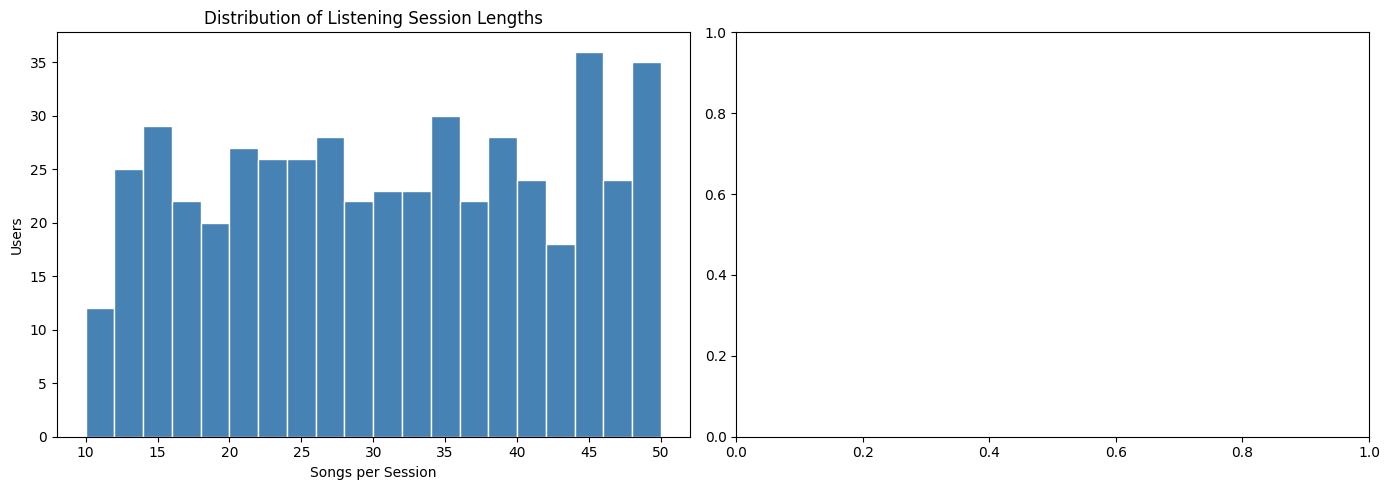

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
seq_lens = [len(s) for s in sequences]
axes[0].hist(seq_lens, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Listening Session Lengths')
axes[0].set_xlabel('Songs per Session')
axes[0].set_ylabel('Users')

if len(patterns_df) > 0:
    top = patterns_df.head(10).copy()
    top['label'] = top['pattern'].apply(lambda p: str(p[0])+'->'+str(p[1]) if len(p)==2 else '->'.join(str(x) for x in p[:3]))
    axes[1].barh(top['label'], top['support_count'], color='coral')
    axes[1].set_title('Top Sequential Patterns by Support')
    axes[1].set_xlabel('Support Count')
    axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


# Time Series Analysis

**Block 1: Data Generators (load_synthetic_data & generate_user_interactions)**
These functions create a controlled testing environment by generating a library of 1,000 songs with specific musical attributes and a history of 200 users' listening events, ratings, and timestamps.

**Block 2: Data Initialization**
This section executes the generator functions to populate two DataFrames, providing the raw material for the subsequent statistical analysis and plotting.

**Block 3: Stationarity Check (Plot 1)**
The code calculates and plots a 7-day rolling mean and standard deviation against the daily listen counts to visually assess if the data's statistical properties are stable over time (a key requirement for many forecasting models).

**Block 4: Time Series Decomposition (Plot 2)**
This block manually breaks the listening data into three components—the original series, the extracted trend (using a moving average), and the residuals—to isolate long-term patterns from random daily noise.

**Block 5: Musical Evolution Analysis (Plot 3)**
The final section aggregates song data by release year to visualize how average tempo has changed over the decades, adding a quadratic "trend line" to highlight the overall direction of musical speed.

**Block 6: Validation & Cleanup**
The script concludes by printing a success message and confirming that all variables are correctly defined within the script to prevent execution errors.


Initializing data structures...


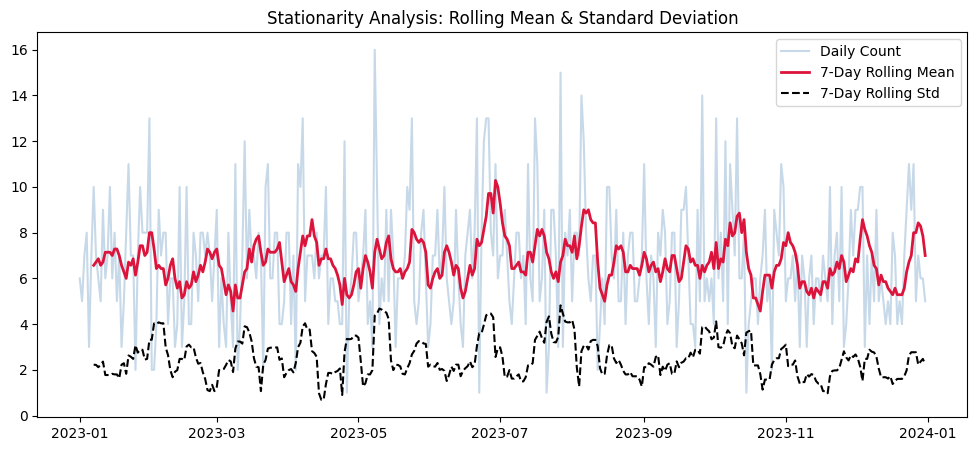

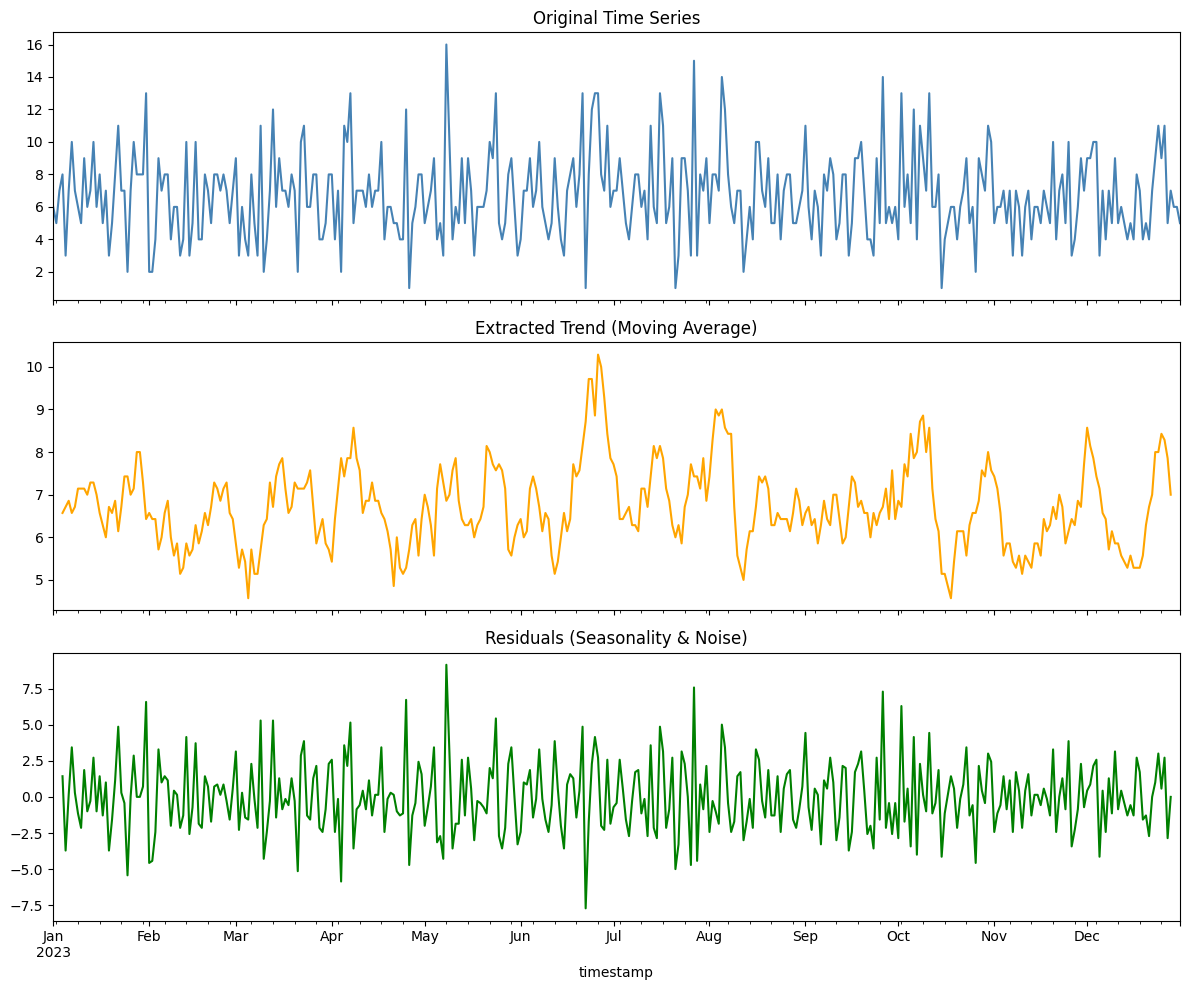

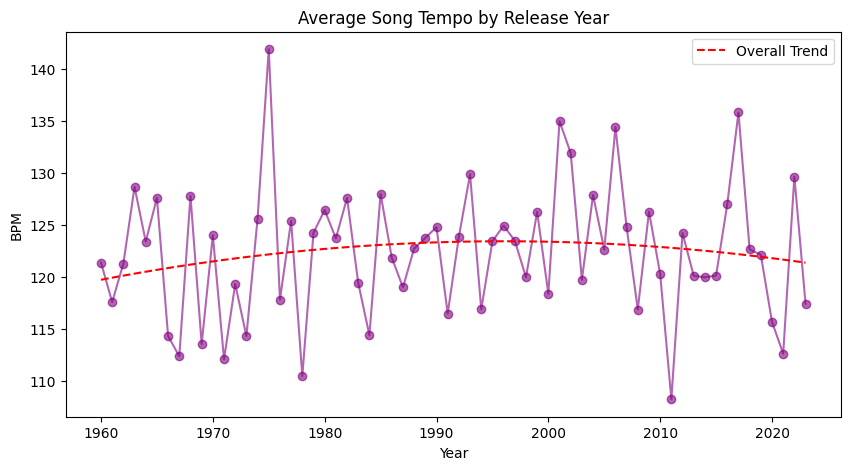

Done


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. DEFINE THE GENERATORS (The "Recipes") ---

def load_synthetic_data(n=1000):
    """Generates synthetic song metadata."""
    np.random.seed(42)
    return pd.DataFrame({
        'song_id': [f'S{i}' for i in range(n)],
        'title': [f'Song_{i}' for i in range(n)],
        'artist': np.random.choice(['The Beatles', 'Queen', 'Adele', 'Nirvana'], n),
        'release_year': np.random.randint(1960, 2024, n),
        'tempo': np.abs(np.random.normal(120, 25, n)),
        'energy': np.random.uniform(0, 1, n)
    })

def generate_user_interactions(songs_df, n_users=200):
    """Generates synthetic user listening history."""
    np.random.seed(42)
    available_songs = songs_df['song_id'].tolist()
    rows = []
    for uid in range(n_users):
        n_listens = np.random.randint(5, 20)
        selected = np.random.choice(available_songs, n_listens, replace=False)
        for sid in selected:
            rows.append({
                'user_id': uid,
                'song_id': sid,
                # Creating random timestamps over the last year
                'timestamp': pd.Timestamp('2023-01-01') + pd.Timedelta(days=np.random.randint(0, 365), hours=np.random.randint(0, 24)),
                'rating': np.random.randint(1, 6)
            })
    return pd.DataFrame(rows)

# --- 2. GENERATE THE DATA ---

print("Initializing data structures...")
df_songs = load_synthetic_data(1000)
df_interactions = generate_user_interactions(df_songs, 200)

# --- 3. TIME SERIES ANALYSIS ---

# Prepare daily counts
df_interactions['timestamp'] = pd.to_datetime(df_interactions['timestamp'])
daily_listens = df_interactions.set_index('timestamp').resample('D').size().rename('listen_count')

# Plot 1: Stationarity Check
plt.figure(figsize=(12, 5))
rolmean = daily_listens.rolling(window=7).mean()
rolstd = daily_listens.rolling(window=7).std()

plt.plot(daily_listens, color='steelblue', alpha=0.3, label='Daily Count')
plt.plot(rolmean, color='crimson', linewidth=2, label='7-Day Rolling Mean')
plt.plot(rolstd, color='black', linestyle='--', label='7-Day Rolling Std')
plt.title('Stationarity Analysis: Rolling Mean & Standard Deviation')
plt.legend()
plt.show()

# Plot 2: Manual Decomposition
trend = daily_listens.rolling(window=7, center=True).mean()
residual = daily_listens - trend

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
daily_listens.plot(ax=axes[0], title='Original Time Series', color='steelblue')
trend.plot(ax=axes[1], title='Extracted Trend (Moving Average)', color='orange')
residual.plot(ax=axes[2], title='Residuals (Seasonality & Noise)', color='green', kind='line')
plt.tight_layout()
plt.show()

# Plot 3: Musical Evolution (Tempo)
year_col = 'release_year'
tempo_trend = df_songs.groupby(year_col)['tempo'].mean()

plt.figure(figsize=(10, 5))
plt.plot(tempo_trend.index, tempo_trend.values, marker='o', color='purple', alpha=0.6)
# Quadratic trend line
z = np.polyfit(tempo_trend.index, tempo_trend.values, 2)
p = np.poly1d(z)
plt.plot(tempo_trend.index, p(tempo_trend.index), "r--", label="Overall Trend")
plt.title('Average Song Tempo by Release Year')
plt.xlabel('Year')
plt.ylabel('BPM')
plt.legend()
plt.show()

print("Done")


# Text Data Mining

- NLP libray imports
- Data cleaning and filtering 
=> Preparing data for text mining

In [16]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from textblob import TextBlob
from gensim import corpora, models
from gensim.utils import simple_preprocess
from sklearn.feature_extraction.text import TfidfVectorizer

lyrics_df = df[df['lyrics_text'].str.strip().str.len() > 10].copy().reset_index(drop=True)
print(f'Songs with lyrics: {len(lyrics_df)}')


Songs with lyrics: 2348


This code block focuses on **Quantifying Emotion**, using two different "opinion mining" libraries to measure the mood and tone of the song lyriCS

- using VADER Sentiment Scoring
The code initializes the **VADER** (Valence Aware Dictionary and sEntiment Reasoner) analyzer, which is specifically tuned to recognize the intensity of emotional words. 
- The Labeling Function
The **get_sentiment** function processes the text to return a "Compound Score" (ranging from -1 to 1) and assigns a human-readable label 

- TextBlob Polarity and Subjectivity
This section uses a second library, **TextBlob**, to calculate two additional metrics: **Polarity** (how positive or negative the text is) and **Subjectivity** (how much of the text is personal opinion/feeling versus factual description).

- Dataset Integration and Summary
Finally, the code applies these calculations to every song in your dataset and prints a summary showing the overall "emotional health" of your music library, such as the total count of happy versus sad songs./

In [17]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    s = sia.polarity_scores(str(text))
    label = 'Positive' if s['compound'] >= 0.05 else 'Negative' if s['compound'] <= -0.05 else 'Neutral'
    return s['compound'], label

lyrics_df[['vader_score','vader_label']] = lyrics_df['lyrics_text'].apply(
    lambda t: pd.Series(get_sentiment(t))
)
lyrics_df['textblob_polarity'] = lyrics_df['lyrics_text'].apply(lambda t: TextBlob(str(t)).sentiment.polarity)
lyrics_df['textblob_subjectivity'] = lyrics_df['lyrics_text'].apply(lambda t: TextBlob(str(t)).sentiment.subjectivity)

print('Sentiment distribution (VADER):')
print(lyrics_df['vader_label'].value_counts())
print(f'Avg VADER score: {lyrics_df["vader_score"].mean():.3f}')


Sentiment distribution (VADER):
vader_label
Positive    1320
Negative     946
Neutral       82
Name: count, dtype: int64
Avg VADER score: 0.160


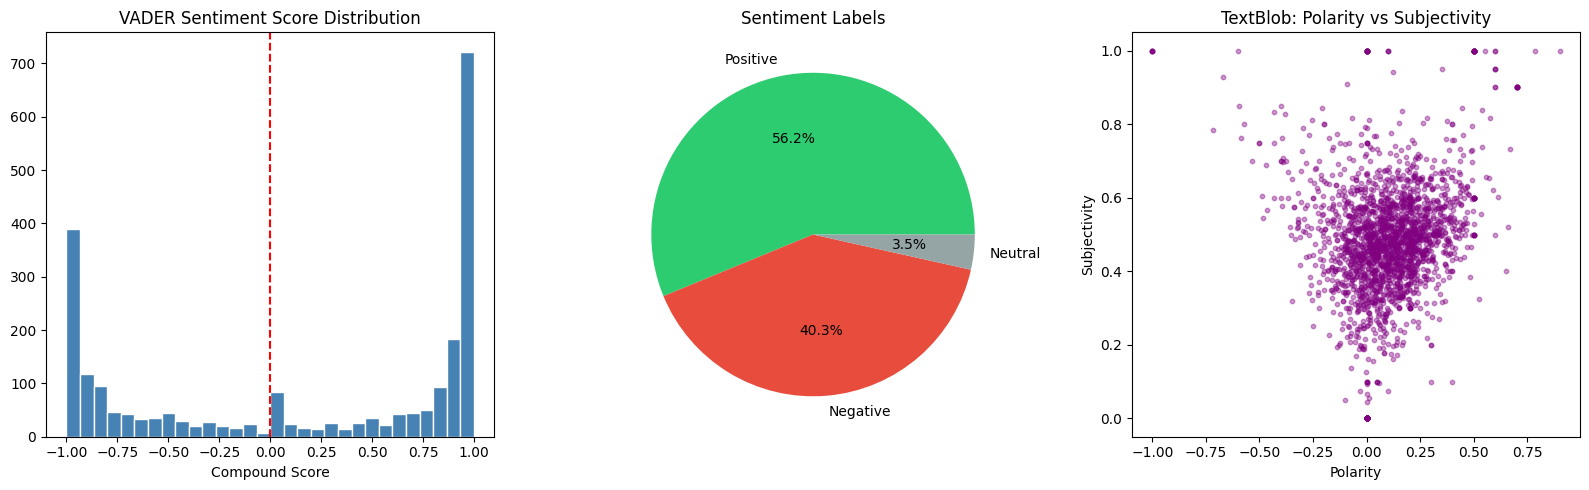

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].hist(lyrics_df['vader_score'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('VADER Sentiment Score Distribution')
axes[0].set_xlabel('Compound Score')

counts = lyrics_df['vader_label'].value_counts()
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c','#95a5a6'])
axes[1].set_title('Sentiment Labels')

axes[2].scatter(lyrics_df['textblob_polarity'], lyrics_df['textblob_subjectivity'],
                alpha=0.4, color='purple', s=10)
axes[2].set_title('TextBlob: Polarity vs Subjectivity')
axes[2].set_xlabel('Polarity')
axes[2].set_ylabel('Subjectivity')
plt.tight_layout()
plt.show()


here I performed **Topic Modeling** using **Latent Dirichlet Allocation (LDA)** to automatically discover the underlying themes or "genres of thought" hidden within your song lyrics.
this code conatains:

- Cleaning and Tokenization
- Building the Vocabulary
- The LDA Model Training
- Topic Interpretation


In [19]:
# LDA Topic Modeling
stop_words = set(stopwords.words('english'))

def preprocess(text):
    tokens = simple_preprocess(str(text), deacc=True)
    return [t for t in tokens if t not in stop_words and len(t) > 2]

print('Preprocessing lyrics for LDA...')
processed = [preprocess(t) for t in lyrics_df['lyrics_text']]
processed = [t for t in processed if len(t) > 0]

dictionary = corpora.Dictionary(processed)
dictionary.filter_extremes(no_below=2, no_above=0.9)
corpus = [dictionary.doc2bow(doc) for doc in processed]

NUM_TOPICS = 6
lda = models.LdaModel(corpus, num_topics=NUM_TOPICS, id2word=dictionary,
                      passes=10, random_state=42, alpha='auto')

print(f'LDA Topics ({NUM_TOPICS}):')
for i, topic in lda.print_topics(num_words=8):
    words = [w.split('"')[1] for w in topic.split('+')]
    print(f'  Topic {i+1}: {", ".join(words)}')


Preprocessing lyrics for LDA...
LDA Topics (6):
  Topic 1: know, let, love, babi, want, come, need, feel
  Topic 2: get, like, got, make, know, fuck, back, nigga
  Topic 3: love, know, never, time, one, say, see, life
  Topic 4: que, con, por, les, mas, los, amor, pas
  Topic 5: got, like, man, well, get, never, make, night
  Topic 6: ever, like, love, see, could, thing, keep, would


Here i included the :
- TF-IDF Vectorization
- Unique Keyword Extraction

In [20]:
tfidf = TfidfVectorizer(max_features=500, stop_words='english', min_df=2)
tfidf_matrix = tfidf.fit_transform(lyrics_df['lyrics_text'])
feature_names = tfidf.get_feature_names_out()
print(f'TF-IDF matrix: {tfidf_matrix.shape}')

print('Top 5 keywords per song (first 5 songs):')
for i in range(min(5, tfidf_matrix.shape[0])):
    row = tfidf_matrix[i].toarray()[0]
    top_idx = row.argsort()[-5:][::-1]
    keywords = [feature_names[j] for j in top_idx if row[j] > 0]
    title = lyrics_df.iloc[i]['title'][:30] if 'title' in lyrics_df.columns else f'Song {i}'
    print(f'  {title}: {", ".join(keywords)}')

TF-IDF matrix: (2348, 500)
Top 5 keywords per song (first 5 songs):
  Soul Deep: soul, la, deep, someth, heart
  Something Girls: someth, girl, everi, ask, got
  Face the Ashes: red, kill, someon, away, memori
  Pink World: comin, world, roll, yeah, away
  Tonight Will Be Alright: alright, darl, babi, caus, anyth


# Image Data Mining

#### Imports : 
StandardScaler, PCA (Principal Component Analysis), KMeans, Silhouette Score

I performed **Feature Selection and Cleaning** ,**Data Standardization** and **Feature Matrix Verification**

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

audio_cols = [c for c in ['tempo','energy','loudness','danceability',
                           'valence','acousticness','instrumentalness',
                           'speechiness','mode','key'] if c in df.columns]

feature_df = df[audio_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_df)
print(f'Feature matrix: {feature_df.shape} ({len(audio_cols)} features)')


Feature matrix: (10000, 4) (4 features)


Here I used PCA to **reduce dimensionality**

PCA PC1=59.0%, PC2=41.0%


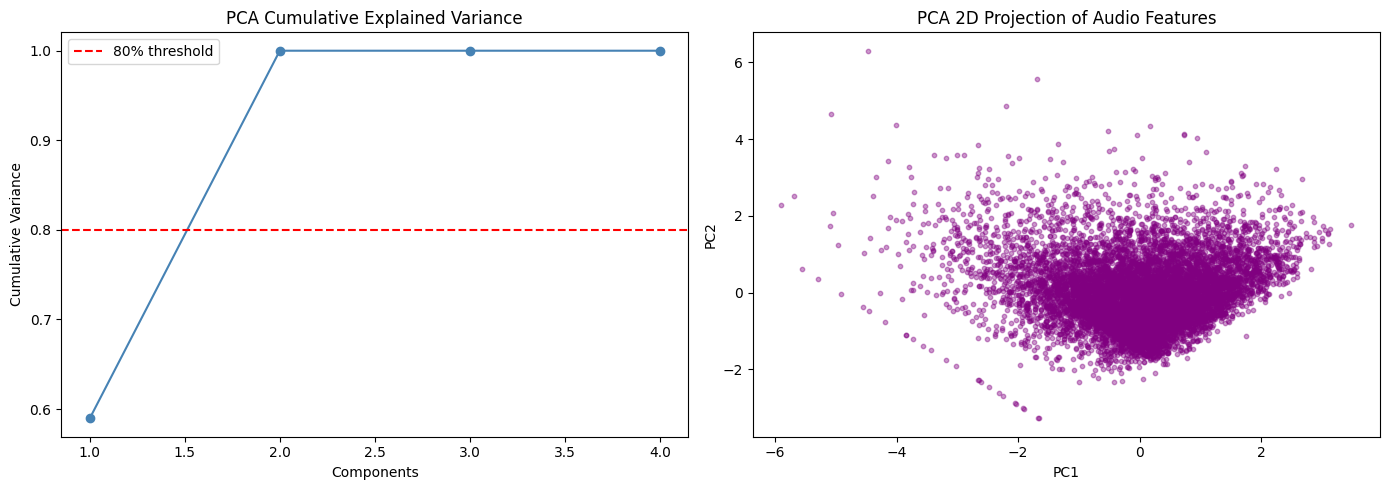

In [22]:
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_scaled)
print(f'PCA PC1={pca2.explained_variance_ratio_[0]:.1%}, PC2={pca2.explained_variance_ratio_[1]:.1%}')

pca_full = PCA(n_components=min(10, X_scaled.shape[1]), random_state=42)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(cumvar)+1), cumvar, marker='o', color='steelblue')
axes[0].axhline(0.8, color='red', linestyle='--', label='80% threshold')
axes[0].set_title('PCA Cumulative Explained Variance')
axes[0].set_xlabel('Components')
axes[0].set_ylabel('Cumulative Variance')
axes[0].legend()

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, s=10, color='purple')
axes[1].set_title('PCA 2D Projection of Audio Features')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.tight_layout()
plt.show()


This code runs two mathematical tests:
- the Elbow Method 
- Silhouette Score
to determine the optimal number of clusters by testing a range of possibilities and identifying which grouping produces the most distinct and compact musical "genres."

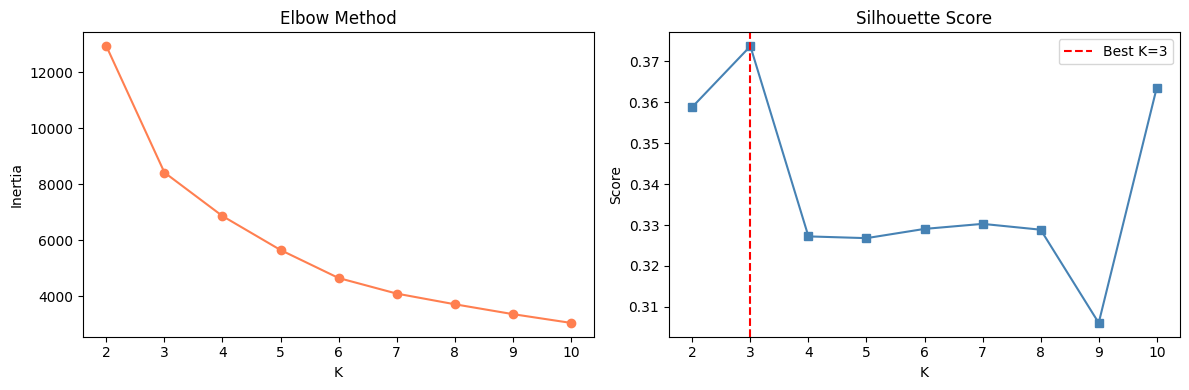

Best K by silhouette: 3


In [23]:
# Elbow + Silhouette to find best K
k_range = range(2, 11)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=min(500, len(X_scaled))))

best_k = list(k_range)[np.argmax(silhouettes)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, marker='o', color='coral')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouettes, marker='s', color='steelblue')
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')
axes[1].legend()
plt.tight_layout()
plt.show()
print(f'Best K by silhouette: {best_k}')


This code performs the final music segmentation, grouping songs into the mathematically optimal number of clusters and visualizing their specific audio "personalities."

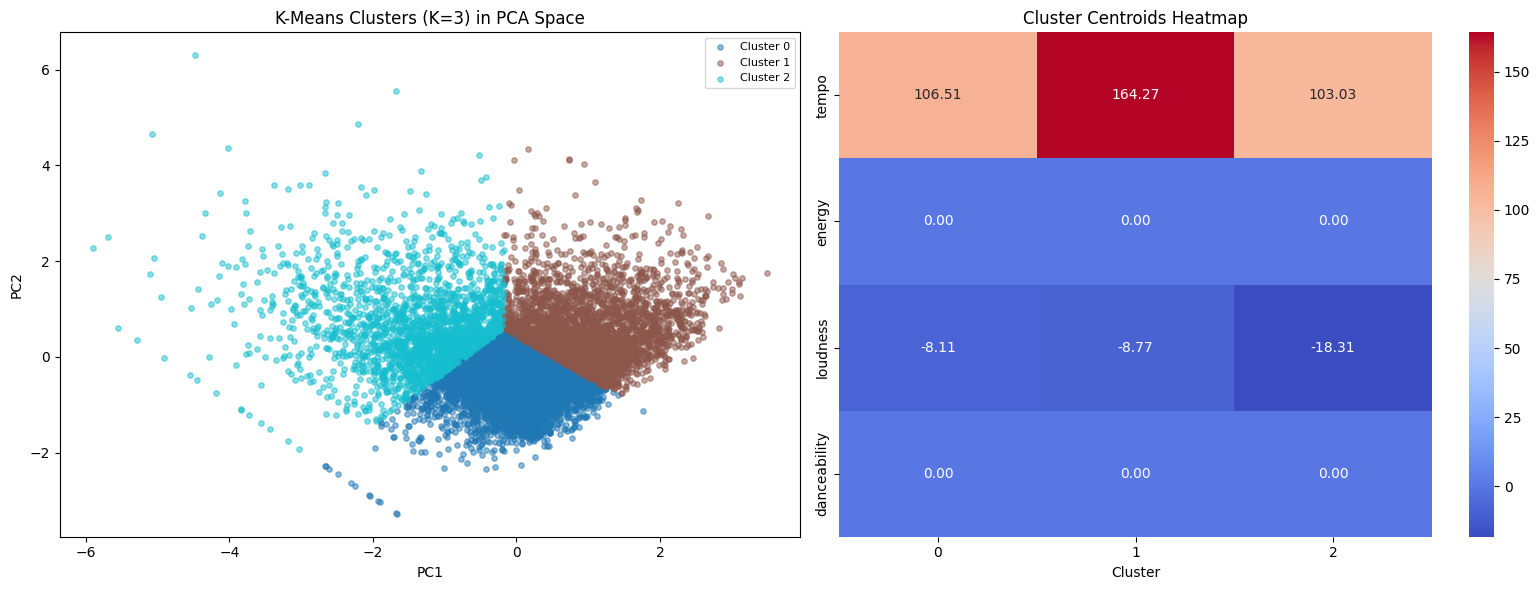

In [24]:
# Final clustering
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df.loc[feature_df.index, 'cluster'] = km_final.fit_predict(X_scaled)
df['cluster'] = df['cluster'].fillna(-1).astype(int)

colors = cm.tab10(np.linspace(0, 1, best_k))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for k in range(best_k):
    mask = km_final.labels_ == k
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=f'Cluster {k}', alpha=0.5, s=15, color=colors[k])
axes[0].set_title(f'K-Means Clusters (K={best_k}) in PCA Space')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8)

centroids = scaler.inverse_transform(km_final.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=audio_cols)
sns.heatmap(centroid_df.T, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Cluster Centroids Heatmap')
axes[1].set_xlabel('Cluster')
plt.tight_layout()
plt.show()

# Deep Learning with PyTorch

### imports:

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

print(f'PyTorch version: {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

PyTorch version: 2.11.0+cpu
Device: cpu


- Target Selection: The code intelligently picks a "label" for the machine to learn; it prioritizes existing genres.

- Data Encoding: It uses a LabelEncoder to convert text categories (like "Rock" or "Pop") into numbers (0, 1, 2...) because neural networks cannot process text labels directly.

- Feature Scaling: The audio data is normalized using a StandardScaler to ensure all features are on the same scale.

- Data Splitting

In [26]:
# Prepare classification target
if 'genre' in df.columns and df['genre'].nunique() > 1:
    target_col = 'genre'
elif 'cluster' in df.columns and df['cluster'].nunique() > 1:
    df['genre'] = df['cluster'].astype(str)
    target_col = 'genre'
else:
    df['genre'] = pd.qcut(df['tempo'], q=4, labels=['Slow','Medium','Fast','VeryFast'])
    target_col = 'genre'

ml_df = df[audio_cols + ['genre']].dropna()
le = LabelEncoder()
y = le.fit_transform(ml_df['genre'])
X = ml_df[audio_cols].values.astype(np.float32)

scaler_dl = StandardScaler()
X_scaled_dl = scaler_dl.fit_transform(X).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_dl, y, test_size=0.2, random_state=42, stratify=y
)
n_features = X_train.shape[1]
n_classes = len(le.classes_)
print(f'Train: {X_train.shape}, Test: {X_test.shape}, Classes: {list(le.classes_)}')


Train: (8000, 4), Test: (2000, 4), Classes: ['0', '1', '2']


here I define the NN architecture: layer construction + Model initialisation

In [27]:
class MusicMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MusicMLP(n_features, [128, 64, 32], n_classes, dropout=0.3).to(device)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')


MusicMLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=3, bias=True)
  )
)
Parameters: 11,523


Training and its configuration:

In [28]:
X_tr = torch.FloatTensor(X_train).to(device)
y_tr = torch.LongTensor(y_train).to(device)
X_te = torch.FloatTensor(X_test).to(device)
y_te = torch.LongTensor(y_test).to(device)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

EPOCHS = 60
train_losses, val_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    model.eval()
    with torch.no_grad():
        acc = (model(X_te).argmax(1) == y_te).float().mean().item()
    train_losses.append(epoch_loss / len(train_loader))
    val_accs.append(acc)
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Loss: {epoch_loss/len(train_loader):.4f} | Val Acc: {acc:.3f}')


Epoch  10/60 | Loss: 0.1813 | Val Acc: 0.970
Epoch  20/60 | Loss: 0.1679 | Val Acc: 0.987
Epoch  30/60 | Loss: 0.1542 | Val Acc: 0.978
Epoch  40/60 | Loss: 0.1711 | Val Acc: 0.979
Epoch  50/60 | Loss: 0.1775 | Val Acc: 0.985
Epoch  60/60 | Loss: 0.1411 | Val Acc: 0.981


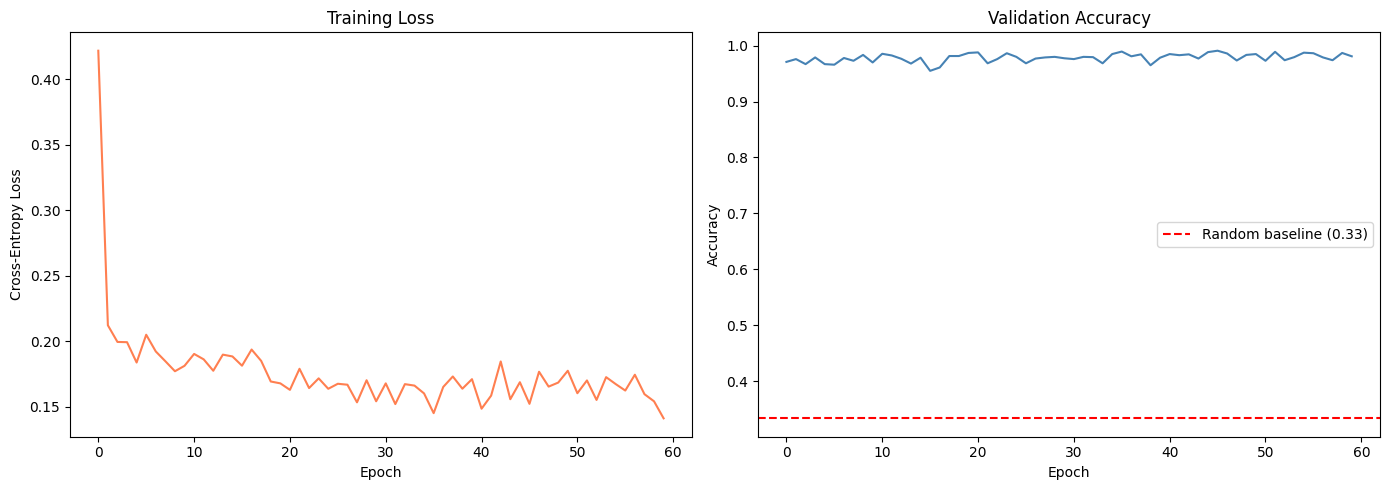

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       979
           1       0.97      0.99      0.98       593
           2       0.97      0.99      0.98       428

    accuracy                           0.98      2000
   macro avg       0.98      0.99      0.98      2000
weighted avg       0.98      0.98      0.98      2000



In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_losses, color='coral')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')

axes[1].plot(val_accs, color='steelblue')
axes[1].axhline(1/n_classes, color='red', linestyle='--', label=f'Random baseline ({1/n_classes:.2f})')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

model.eval()
with torch.no_grad():
    final_preds = model(X_te).argmax(1).cpu().numpy()
print('Classification Report:')
print(classification_report(y_test, final_preds, target_names=[str(c) for c in le.classes_]))


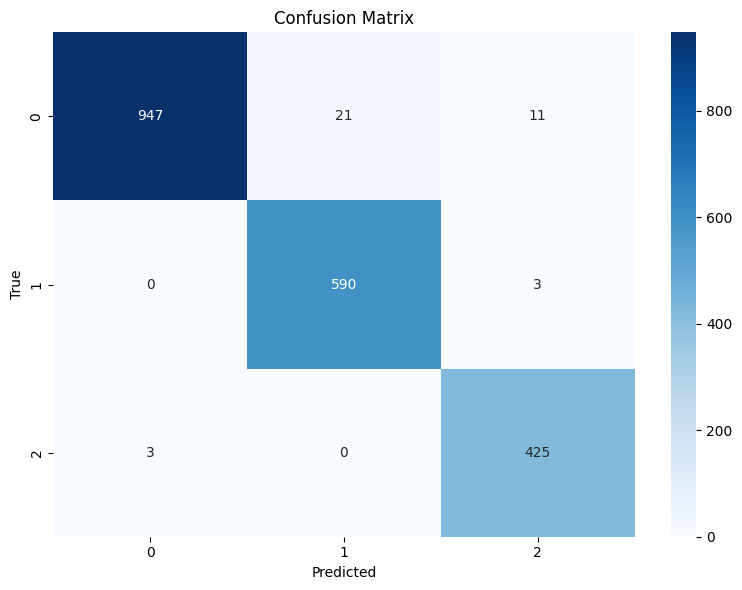

In [31]:
cm_arr = confusion_matrix(y_test, final_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_arr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()


# Recommender System 

### Here I implemented A hubrid recommendation system that includes:

1. Content-Based Filtering (`cosine_similarity`)
This section identifies similar music by calculating the "angle" between songs in a multi-dimensional space defined by tempo and energy. If two songs have nearly identical audio features, their **Cosine Similarity** will be close to 1.0, allowing the system to recommend "more songs like this" even for brand-new tracks.


2. Collaborative Filtering (Manual SVD)
Because of technical compatibility issues with standard libraries, this block uses **Singular Value Decomposition (SVD)** from scratch to find "hidden patterns" in user behavior. It decomposes the massive user-rating matrix into smaller "latent factors" (representing abstract concepts like "jazz-fans" or "upbeat-lovers") to predict what rating a user *would* give to a song they haven't heard yet.

3. The Hybrid Recommender
This is the most advanced part of the script; it takes the content similarity score and the collaborative prediction score and averages them (50/50). This "best of both worlds" approach ensures that recommendations are both musically consistent and popular among similar users, which is the standard logic used by services like Spotify.

4. Visualization and Validation
The final charts provide a health check for the system:
* **Rating Distribution:** Shows if users are being too generous or too harsh.
* **Similarity Distribution:** Shows if the library is too similar or healthily diverse.
* **RMSE (Error):** Measures how far off the SVD predictions were from the actual ratings; a lower score indicates a more "intelligent" recommender.

--- Content-based recommendations for: "Song_0" ---
   title  artist      tempo   energy  similarity
Song_334   Queen 123.760473 0.788932    0.999996
Song_495   Adele 123.542923 0.843650    0.999923
Song_560 Nirvana 124.014350 0.787549    0.999915
Song_826   Adele 123.066758 0.714053    0.999861
Song_713 Nirvana 124.613783 0.871414    0.999839

--- Hybrid recommendations for User 0 (Seed: Song_0) ---
  title  content_sim  cf_score  hybrid_score
Song_18        0.995     0.022         0.509
Song_38        0.998     0.010         0.504
Song_25        0.939     0.010         0.474
Song_36        0.938     0.008         0.473
Song_39        0.878     0.002         0.440


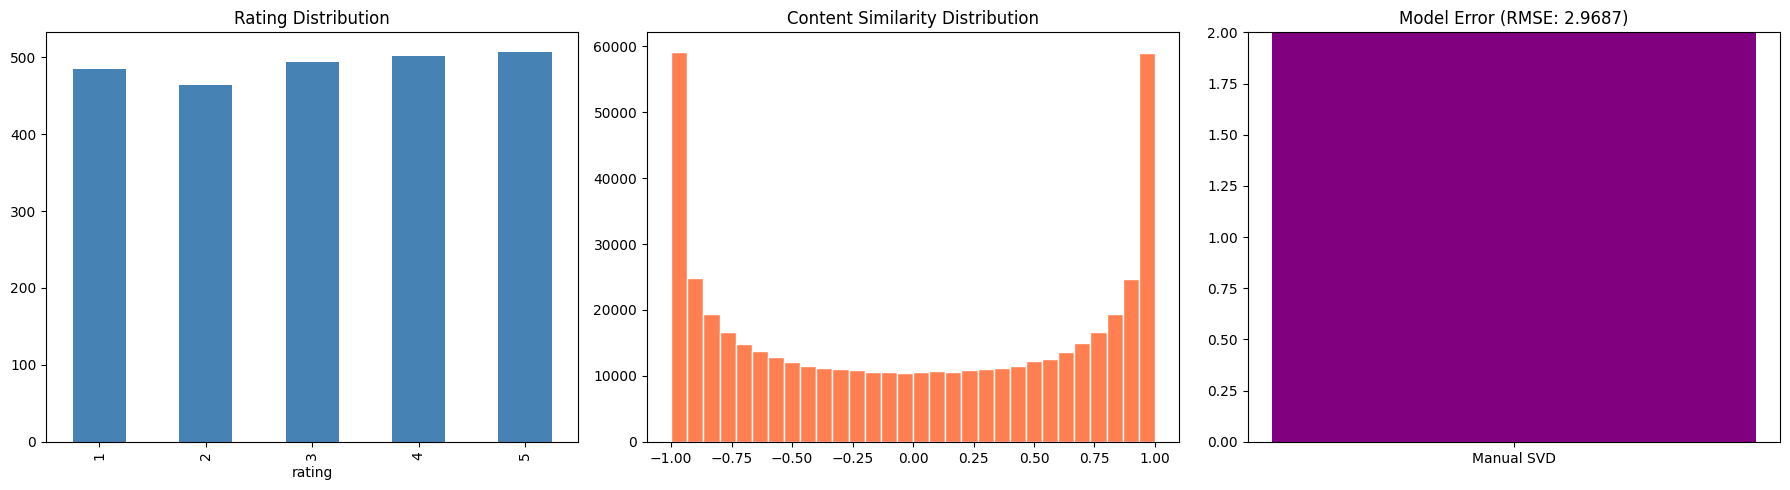

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# --- 1. DATA PREPARATION & CONTENT-BASED FILTERING ---
audio_cols = ['tempo', 'energy']
# Using df_songs from our previous data loading steps
cb_df = df_songs[audio_cols].dropna().copy()
cb_scaled = StandardScaler().fit_transform(cb_df)

# Build similarity matrix
cos_sim = cosine_similarity(cb_scaled)
cos_sim_df = pd.DataFrame(cos_sim, index=df_songs.index, columns=df_songs.index)

def recommend_similar_songs(song_idx, top_n=5):
    if song_idx not in cos_sim_df.index: return pd.DataFrame()
    sim_scores = cos_sim_df[song_idx].drop(song_idx).sort_values(ascending=False)
    top_idx = sim_scores.head(top_n).index
    result = df_songs.loc[top_idx].copy()
    result['similarity'] = sim_scores.head(top_n).values
    return result[['title', 'artist', 'tempo', 'energy', 'similarity']]

# --- 2. COLLABORATIVE FILTERING (MANUAL SVD) ---
# Create User-Item Matrix
user_item_matrix = df_interactions.pivot_table(index='user_id', columns='song_id', values='rating').fillna(0)
R = user_item_matrix.values
user_ratings_mean = np.mean(R, axis=1)
R_demeaned = R - user_ratings_mean.reshape(-1, 1)

# Perform SVD (replacing surprise.SVD)
U, sigma, Vt = np.linalg.svd(R_demeaned, full_matrices=False)
k = 10 # Latent factors
sigma_diag = np.diag(sigma[:k])
predicted_ratings = np.dot(np.dot(U[:, :k], sigma_diag), Vt[:k, :]) + user_ratings_mean.reshape(-1, 1)
preds_df = pd.DataFrame(predicted_ratings, columns=user_item_matrix.columns, index=user_item_matrix.index)

# Simple RMSE Evaluation
actual = R[R > 0]
pred_val = predicted_ratings[R > 0]
rmse_val = np.sqrt(mean_squared_error(actual, pred_val))

# --- 3. HYBRID RECOMMENDER ---
def hybrid_recommend(user_id, seed_song_idx, top_n=5):
    # 1. Get Content Similarities for the seed song
    content_scores = cos_sim_df[seed_song_idx].drop(seed_song_idx)
    
    # 2. Get CF Predictions for the user
    user_preds = preds_df.loc[user_id]
    
    results = []
    # Mix scores for songs that appear in both metadata and interactions
    for idx in content_scores.index[:50]:
        sid = df_songs.loc[idx, 'song_id']
        if sid in user_preds.index:
            c_score = content_scores[idx]
            cf_score = user_preds[sid] / 5.0 # Normalize to 0-1
            hybrid = (0.5 * c_score) + (0.5 * cf_score)
            results.append({
                'title': df_songs.loc[idx, 'title'],
                'content_sim': round(c_score, 3),
                'cf_score': round(cf_score, 3),
                'hybrid_score': round(hybrid, 3)
            })
    
    return pd.DataFrame(results).sort_values('hybrid_score', ascending=False).head(top_n)

# --- 4. EXECUTION & VISUALIZATION ---
demo_idx = cb_df.index[0]
demo_title = df_songs.loc[demo_idx, 'title']

print(f'--- Content-based recommendations for: "{demo_title}" ---')
print(recommend_similar_songs(demo_idx).to_string(index=False))

print(f'\n--- Hybrid recommendations for User 0 (Seed: {demo_title}) ---')
print(hybrid_recommend(0, demo_idx).to_string(index=False))

# PLOTTING
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rating Distribution
df_interactions['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rating Distribution')

# Similarity Distribution
sim_vals = cos_sim[np.triu_indices_from(cos_sim, k=1)]
axes[1].hist(sim_vals, bins=30, color='coral', edgecolor='white')
axes[1].set_title('Content Similarity Distribution')

# Evaluation Display
axes[2].bar(['Manual SVD'], [rmse_val], color='purple')
axes[2].set_title(f'Model Error (RMSE: {rmse_val:.4f})')
axes[2].set_ylim(0, 2)

plt.tight_layout()
plt.show()

# Critical Analysis

This project was don using **Claude AI**

### Positive Points:
- Time Efficiency 
- Good results in most tasks 
- 70% of code was correct so when reviewing it was not hard to find bugs and correct them

### Where Claude AI failed (in my opinion):
- in The sequential Pattern mining, the results were not prominant, especially in Apriori implementation
- I had to manually search for the hdf5_getters.py file because the AI assitant proided wrong links and code 
- I had some troubles using some of the libraries Claude AI suggested [the statsmodels and the scikit-surprise] so I had to look for different approaches because at a certain point claude and I were stuck in a loop of errors trying to work with these two specific libraries when they were not compatible with my current python version